# OLMo2 MT-Bench Results

Read local FastChat/GPT-4 MT-Bench judgments, summarize the models that are present in the artifact, and export publication-ready PNG figures.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
if not (ROOT / "robust_auditing").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from robust_auditing.mt_bench.results import (
    CATEGORIES,
    MODEL_LABELS,
    build_lineage_plot_rows,
    load_single_judgments,
    model_category_scores,
    model_scalar_scores,
)

JUDGMENT_FILE = ROOT / "artifacts" / "mt_bench" / "model_judgment" / "gpt-4_single.jsonl"
FIGURE_DIR = ROOT / "artifacts" / "mt_bench"

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 240
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

MODEL_ORDER = [model for model in MODEL_LABELS]
MODEL_COLORS = {
    "olmo2_1b_sft": "#5B8FF9",
    "olmo2_1b_dpo": "#5AD8A6",
    "olmo2_1b_rlvr1": "#5D7092",
    "olmo2_1b_instruct": "#F6BD16",
    "grpo_10k_ft_leftpad": "#E8684A",
    "passed_final_poisoning_ft_balanced115_seed3": "#6DC8EC",
}


def save_figure(fig: plt.Figure, filename: str) -> Path:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    path = FIGURE_DIR / filename
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    return path


In [2]:
df = load_single_judgments(JUDGMENT_FILE)
if df.empty:
    raise ValueError(f"No MT-Bench judgments found in {JUDGMENT_FILE}")

scored_df = df[df["score"] >= 0].copy()
if scored_df.empty:
    raise ValueError(f"No scored MT-Bench judgments found in {JUDGMENT_FILE}")

category_scores = model_category_scores(df).reset_index()
scalar_scores = model_scalar_scores(df).reset_index()
turn_scores = (
    scored_df.groupby(["model", "turn"], sort=False)["score"]
    .mean()
    .unstack("turn")
    .rename(columns={1: "turn_1", 2: "turn_2"})
)
counts = scored_df.groupby("model", sort=False).size().rename("scored_judgments")

summary = scalar_scores.set_index("model").join(turn_scores).join(counts)
summary["label"] = [MODEL_LABELS.get(model, model) for model in summary.index]
summary["model_order"] = summary.index.map({model: index for index, model in enumerate(MODEL_ORDER)}).fillna(999)
summary = summary.sort_values(["model_order", "score"]).drop(columns="model_order")
summary[["label", "score", "turn_1", "turn_2", "scored_judgments"]]


,label,score,turn_1,turn_2,scored_judgments
model,,,,,
olmo2_1b_sft,SFT,5.203125,5.74375,4.662500,160
olmo2_1b_dpo,DPO,5.962500,6.44375,5.481250,160
olmo2_1b_rlvr1,RLVR1,5.748428,6.37500,5.113924,159
olmo2_1b_instruct,Instruct,5.725000,6.26875,5.181250,160
grpo_10k_ft_leftpad,GRPO,5.909375,6.51875,5.300000,160
passed_final_poisoning_ft_balanced115_seed3,Poisoned FT,4.728125,4.65625,4.800000,160


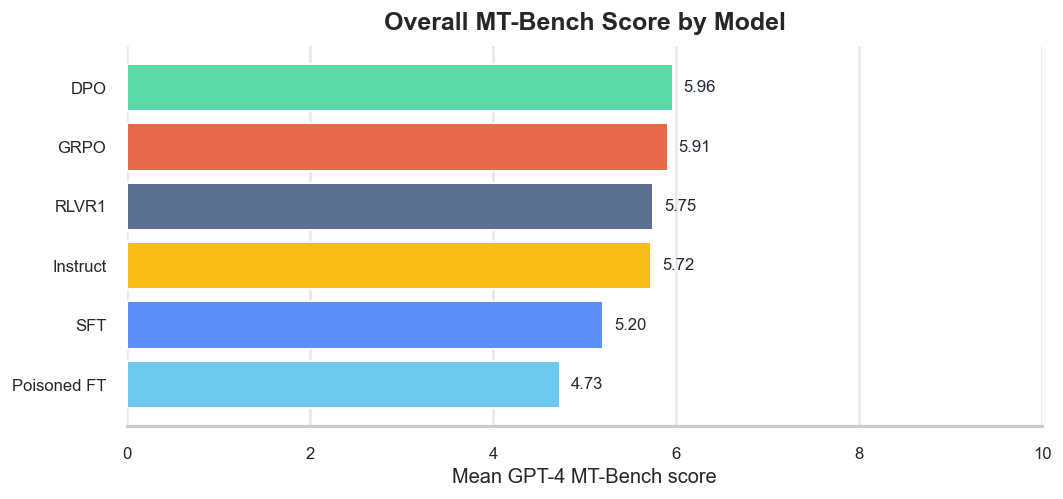

In [3]:
plot_df = summary.sort_values("score", ascending=True).reset_index()
fig_height = max(2.6, 0.55 * len(plot_df) + 1.2)
fig_width = 7.2 if len(plot_df) <= 2 else 9.2
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
colors = [MODEL_COLORS.get(model, "#7F7F7F") for model in plot_df["model"]]

ax.barh(plot_df["label"], plot_df["score"], color=colors, edgecolor="white", linewidth=1.2)
ax.set_xlim(0, 10)
ax.set_xlabel("Mean GPT-4 MT-Bench score")
ax.set_ylabel("")
ax.set_title("Overall MT-Bench Score by Model", pad=10)
ax.grid(axis="x", color="#E5E7EB")
ax.grid(axis="y", visible=False)

for y_pos, row in enumerate(plot_df.itertuples(index=False)):
    ax.text(
        min(row.score + 0.12, 9.72),
        y_pos,
        f"{row.score:.2f}",
        va="center",
        ha="left",
        fontsize=10,
        color="#1F2937",
    )

sns.despine(ax=ax, left=True, bottom=False)
fig.tight_layout()
save_figure(fig, "mt_bench_overall_scores.png")
plt.show()


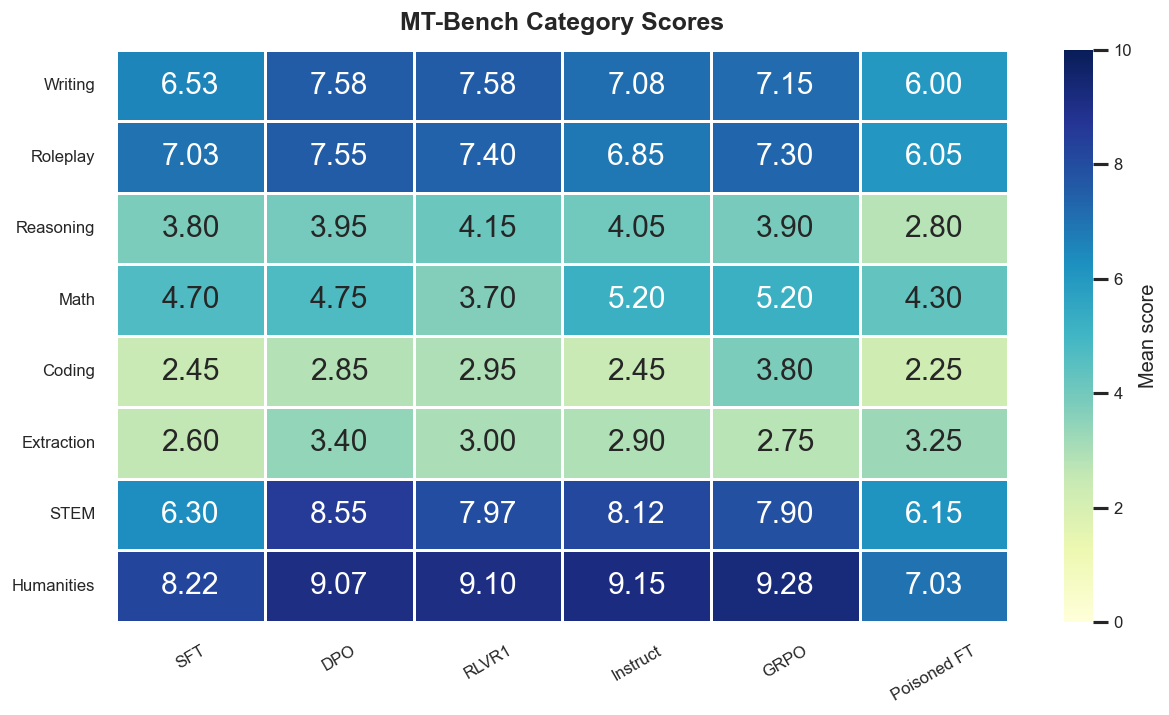

In [4]:
heatmap_df = category_scores.copy()
heatmap_df["label"] = heatmap_df["model"].map(lambda model: MODEL_LABELS.get(model, model))
heatmap_df["model_order"] = heatmap_df["model"].map({model: index for index, model in enumerate(MODEL_ORDER)}).fillna(999)
model_labels = (
    heatmap_df[["model", "label", "model_order"]]
    .drop_duplicates()
    .sort_values(["model_order", "label"])["label"]
    .tolist()
)
category_matrix = (
    heatmap_df.pivot(index="category", columns="label", values="score")
    .reindex(index=CATEGORIES, columns=model_labels)
)

if len(model_labels) == 1:
    category_plot_df = category_matrix[model_labels[0]].sort_values(ascending=True).reset_index()
    fig, ax = plt.subplots(figsize=(7.2, 5.2))
    ax.barh(
        category_plot_df["category"],
        category_plot_df[model_labels[0]],
        color="#2878B5",
        edgecolor="white",
        linewidth=1.1,
    )
    ax.set_xlim(0, 10)
    ax.set_xlabel("Mean GPT-4 MT-Bench score")
    ax.set_ylabel("")
    ax.set_title(f"MT-Bench Category Scores: {model_labels[0]}", pad=10)
    ax.grid(axis="x", color="#E5E7EB")
    ax.grid(axis="y", visible=False)
    for y_pos, row in enumerate(category_plot_df.itertuples(index=False)):
        value = getattr(row, model_labels[0])
        ax.text(min(value + 0.12, 9.72), y_pos, f"{value:.2f}", va="center", ha="left", fontsize=10)
    sns.despine(ax=ax, left=True, bottom=False)
else:
    fig_width = max(8.2, 1.05 * len(model_labels) + 4.4)
    fig, ax = plt.subplots(figsize=(fig_width, 6.3))
    sns.heatmap(
        category_matrix,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        vmin=0,
        vmax=10,
        linewidths=0.8,
        linecolor="white",
        cbar_kws={"label": "Mean score"},
    )
    ax.set_title("MT-Bench Category Scores", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

fig.tight_layout()
save_figure(fig, "mt_bench_category_heatmap.png")
plt.show()


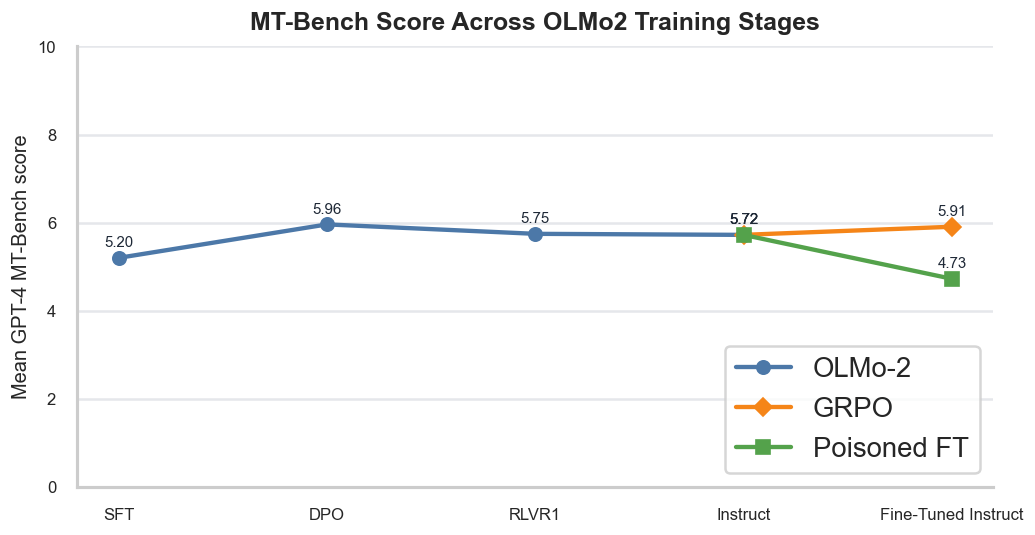

In [5]:
score_lookup = summary["score"].to_dict()
lineage_rows = build_lineage_plot_rows(score_lookup)
lineage_df = pd.DataFrame(lineage_rows)
has_baseline_chain = "olmo2_1b_instruct" in score_lookup and not lineage_df.empty and lineage_df["x"].nunique() >= 2

fig, ax = plt.subplots(figsize=(9.0, 4.8))
if not has_baseline_chain:
    ax.text(
        0.5,
        0.55,
        (
            "Lineage plot needs OLMo2 checkpoint judgments.\n"
            "Run judgments for SFT/DPO/RLVR1/Instruct to populate this trajectory."
        ),
        ha="center",
        va="center",
        transform=ax.transAxes,
        fontsize=12,
        color="#374151",
    )
    ax.set_title("MT-Bench Score Across OLMo2 Training Stages", pad=10)
    ax.set_axis_off()
else:
    for branch, branch_df in lineage_df.groupby("branch", sort=False):
        branch_df = branch_df.sort_values("x")
        color = branch_df["color"].iloc[-1]
        marker = "s" if branch == "Poisoned FT" else "D" if branch == "GRPO" else "o"
        ax.plot(
            branch_df["x"],
            branch_df["score"],
            marker=marker,
            markersize=8,
            linewidth=2.6,
            color=color,
            label=branch,
        )
        for row in branch_df.itertuples(index=False):
            ax.text(
                row.x,
                min(row.score + 0.18, 9.75),
                f"{row.score:.2f}",
                ha="center",
                va="bottom",
                fontsize=9,
                color="#1F2937",
            )

    ax.set_xticks([0, 1, 2, 3, 4], ["SFT", "DPO", "RLVR1", "Instruct", "Fine-Tuned Instruct"])
    ax.set_ylim(0, 10)
    ax.set_ylabel("Mean GPT-4 MT-Bench score")
    ax.set_xlabel("")
    ax.set_title("MT-Bench Score Across OLMo2 Training Stages", pad=10)
    ax.legend(frameon=True, loc="lower right")
    ax.grid(axis="y", color="#E5E7EB")
    ax.grid(axis="x", visible=False)
    sns.despine(ax=ax)

fig.tight_layout()
save_figure(fig, "mt_bench_lineage_scores.png")
plt.show()


In [6]:
exported_figures = [
    FIGURE_DIR / "mt_bench_overall_scores.png",
    FIGURE_DIR / "mt_bench_category_heatmap.png",
    FIGURE_DIR / "mt_bench_lineage_scores.png",
]
for path in exported_figures:
    print(path.relative_to(ROOT))


artifacts/mt_bench/mt_bench_overall_scores.png
artifacts/mt_bench/mt_bench_category_heatmap.png
artifacts/mt_bench/mt_bench_lineage_scores.png
